# 09 — Bugs Found During the EDA

> *"Every mistake is a chance to learn."*
> — Standard scientific method, since approximately forever.

This notebook is **deliberately separate** from the clean modelling notebooks
(02–08) because in the thesis memory we want to give the debugging process the
space it deserves.  The master's project went through a full first draft of
notebooks 02–08 before two silent but fatal bugs were caught in the feature
engineering SQL.  Writing them down here serves three purposes:

1. **Honesty.**  The original project slides (`waze_cargo.pptx`) reported
   LightGBM at R² ≈ 0.909.  After fixing the bugs the honest figure is
   R² ≈ 0.57 (volume-weighted, across three folds).  The difference is not
   cosmetic — it is the gap between a leaked metric and a model that can
   actually be trusted in production.
2. **Repeatability.**  The exact SQL snippets, the evidence, and the fix are
   all captured here so that any future collaborator can understand *why*
   certain columns were dropped from `FEATURE_COLS` in `wz_ml_utils.py`.
3. **Pedagogy.**  Both bugs are classic, textbook examples of target leakage:
   one *spatial* (future-to-past via a full-history window), one *temporal*
   (current-row inclusion in a rolling frame).  They are exactly the kind of
   mistake that any ML practitioner working with time series will meet sooner
   or later.  Making them visible is part of the thesis.

---

## Table of contents

1. [Context — how the bugs were caught](#context)
2. [Bug 1 — full-history min-max normalisation (`sc_norm`, `v_norm`, `w_norm`, `cd_norm`)](#bug1)
3. [Bug 2 — inclusive rolling means (`rolling_3_mean`, `rolling_12_mean`, `rolling_value_12_mean`)](#bug2)
4. [Why trees only leaked *partially* — the asymmetric impact](#asymmetry)
5. [Why the production model still worked — train/serve skew](#skew)
6. [The fix](#fix)
7. [Before-and-after metrics](#metrics)
8. [Lessons learned](#lessons)


<a id="context"></a>
## 1  Context — how the bugs were caught

The EDA was organised as a protocol: every candidate ML model
(baseline, LightGBM, XGBoost, Random Forest, Ridge / Lasso / ElasticNet,
Prophet) goes through the **same** walk-forward CV in `wz_ml_utils.py`,
the **same** feature list, and the **same** scoring function.  Keeping the
protocol identical across notebooks makes the comparison notebook (08) a
fair fight.

When the first draft of all eight notebooks was executed end-to-end, the
comparison table looked like this:


In [1]:
# ── Reproduce the *first-draft* (buggy) metrics from memory ──
# (The leak has since been removed, so we hand-enter the numbers we saw
#  during the first run — they are permanently archived in the thesis log.)
import pandas as pd

first_draft = pd.DataFrame([
    {"model": "ridge",         "median_mae":  0.0, "median_r2": 1.000},
    {"model": "lasso",         "median_mae":  0.1, "median_r2": 1.000},
    {"model": "elasticnet",    "median_mae":  0.1, "median_r2": 1.000},
    {"model": "xgboost",       "median_mae":  3.3, "median_r2": 0.588},
    {"model": "lightgbm",      "median_mae":  3.7, "median_r2": 0.535},
    {"model": "random_forest", "median_mae":  3.6, "median_r2": 0.510},
    {"model": "baseline",      "median_mae":  4.5, "median_r2": -0.479},
    {"model": "prophet",       "median_mae":501.4, "median_r2": -0.072},
])
first_draft = first_draft.sort_values("median_r2", ascending=False).reset_index(drop=True)
first_draft

,model,median_mae,median_r2
0,ridge,0.0,1.000
1,lasso,0.1,1.000
2,elasticnet,0.1,1.000
3,xgboost,3.3,0.588
4,lightgbm,3.7,0.535
5,random_forest,3.6,0.510
6,prophet,501.4,-0.072
7,baseline,4.5,-0.479


**Smell test.**  Ridge, Lasso and ElasticNet — *linear* models on a noisy
count time series — are hitting **R² = 1.000** with **MAE ≈ 0 shipments**
across every port-direction pair in every walk-forward fold.

This is the statistical equivalent of a burglar alarm going off.  No honest
linear model should beat the three tree ensembles on a real forecasting task
by four orders of magnitude.  The only plausible explanation is that the
linear models have found a closed-form identity between some feature(s) and
the target.

The next two sections are the forensic report: exactly which columns leaked,
where the bug is in the SQL, and how the leak was proved.


<a id="bug1"></a>
## 2  Bug 1 — full-history min-max normalisations

### 2.1  The offending SQL

In `03_ml_congestion.sql`, four normalised columns are created for the
**congestion-index formula**:

```sql
-- 03_ml_congestion.sql, lines 142-149 (simplified)
SELECT
    *,
    (shipment_count  - MIN(shipment_count)  OVER pd)
        / NULLIF(MAX(shipment_count)  OVER pd - MIN(shipment_count)  OVER pd, 0) AS sc_norm,
    (total_value_usd - MIN(total_value_usd) OVER pd)
        / NULLIF(MAX(total_value_usd) OVER pd - MIN(total_value_usd) OVER pd, 0) AS v_norm,
    (total_weight_mt - MIN(total_weight_mt) OVER pd)
        / NULLIF(MAX(total_weight_mt) OVER pd - MIN(total_weight_mt) OVER pd, 0) AS w_norm,
    (commodity_diversity - MIN(commodity_diversity) OVER pd)
        / NULLIF(MAX(commodity_diversity) OVER pd - MIN(commodity_diversity) OVER pd, 0) AS cd_norm
FROM base
WINDOW pd AS (PARTITION BY port, direction);
```

**The bug is what's *missing*.**  The window `pd` has

* no `ORDER BY`,
* no `ROWS BETWEEN …` frame bound.

So `MIN(shipment_count) OVER pd` and `MAX(shipment_count) OVER pd` are
computed over the **entire history** of the port — from the first month in
2005 to the last month in 2025.  That global min and max is then broadcast
to every row, **including past rows**.

### 2.2  Why this is a leak

Imagine we are training on data up to December 2018 and predicting January
2019.  The row for **January 2015** has

$$
\text{sc\_norm}_{2015\text{-}01}
 \;=\;
 \frac{\text{shipment\_count}_{2015\text{-}01} - \min_{\text{2005–2025}}}
      {\max_{\text{2005–2025}} - \min_{\text{2005–2025}}}
$$

That denominator contains the 2025 maximum — which is **eleven years in the
future** relative to the training row.  A model fitted on this feature is
being silently told *"the maximum shipment count over the next decade of
this port will be approximately X"*, which is obviously not information a
real 2015 forecaster could have had.

### 2.3  Why it's a *trivial* leak for linear models

`sc_norm` is an affine transformation of `shipment_count`:

$$
\text{sc\_norm}_t \;=\; a \cdot \text{shipment\_count}_t + b
\quad\text{with constants } a, b \text{ per port-direction.}
$$

Inverting:

$$
\text{shipment\_count}_t \;=\; \frac{1}{a} \cdot \text{sc\_norm}_t - \frac{b}{a}
$$

Ridge / Lasso / ElasticNet can learn the two constants in one step.  There is
**nothing to do** after that — the prediction error collapses to round-off
noise, which is why the MAE was 0.0 and R² was 1.000 in every fold.

### 2.4  Design intent vs misuse

These four columns were never intended to be *ML* features.  They exist so
that the downstream congestion-index formula can combine four quantities on
a common 0–1 scale:

```sql
-- 03_ml_congestion.sql, lines 157-162 (congestion-index CTE)
0.40 * sc_norm + 0.25 * w_norm
    + 0.20 * cd_norm + 0.10 * pct_container    AS cong_imp,
0.40 * sc_norm + 0.25 * w_norm
    + 0.20 * v_norm + 0.10 * pct_refrigerated  AS cong_exp,
```

The problem is that the *same* parquet file feeds both the congestion index
**and** the ML training loop in `05_ml_train_evaluate.py`, which iterates
over every numeric column in the feature table.  Nothing told it to skip
`sc_norm`.  So the columns leaked into the model silently.


<a id="bug2"></a>
## 3  Bug 2 — inclusive rolling means

### 3.1  The offending SQL

```sql
-- 03_ml_congestion.sql, lines 121-129 (simplified)
AVG(shipment_count::DOUBLE PRECISION)
    OVER (PARTITION BY port, direction ORDER BY year, month
          ROWS BETWEEN  2 PRECEDING AND CURRENT ROW)   AS rolling_3_mean,

AVG(shipment_count::DOUBLE PRECISION)
    OVER (PARTITION BY port, direction ORDER BY year, month
          ROWS BETWEEN 11 PRECEDING AND CURRENT ROW)   AS rolling_12_mean,

AVG(total_value_usd)
    OVER (PARTITION BY port, direction ORDER BY year, month
          ROWS BETWEEN 11 PRECEDING AND CURRENT ROW)   AS rolling_value_12_mean
```

The bug is the word **`CURRENT ROW`** in the frame bound.  The rolling mean
at time $t$ therefore includes `shipment_count[t]` itself:

$$
\text{rolling\_3\_mean}_t
  \;=\;
  \frac{\text{shipment\_count}_{t-2}
        + \text{shipment\_count}_{t-1}
        + \text{shipment\_count}_{t}}{3}
$$

### 3.2  The closed-form identity

Because `lag_1` and `lag_2` are also features, a linear model can trivially
recover the target:

$$
\boxed{\;\text{shipment\_count}_t
  \;=\; 3 \cdot \text{rolling\_3\_mean}_t
        - \text{lag\_1}_t - \text{lag\_2}_t\;}
$$

That is three features and two coefficients — Ridge/Lasso/ElasticNet can fit
it in essentially zero gradient steps.  `rolling_12_mean` gives a second,
redundant identity for the same target.

### 3.3  The "right" definition

A rolling mean that is safe to use as a feature must be computed over
**past-only** rows:

```sql
-- What it SHOULD say
ROWS BETWEEN  3 PRECEDING AND 1 PRECEDING    -- proper lag-window mean
```

Under this frame, `rolling_3_mean[t]` is the mean of `shipment_count[t-3]`,
`shipment_count[t-2]`, and `shipment_count[t-1]` — all of which are
information a real forecaster would have had at time $t$.

### 3.4  How we proved it

Once the bug was suspected, the verification is a one-liner: fit the
closed-form identity on the real parquet and look at the residual.


In [2]:
# ── Verify the closed-form identity numerically ──────────────────
import sys
sys.path.insert(0, "/home/koko/Waze_Cargo/WazeCargo/notebooks/eda")
import pandas as pd
import numpy as np
from pathlib import Path

raw = pd.read_parquet(Path("/home/koko/Waze_Cargo/WazeCargo/notebooks/eda/data/port_features_indexed.parquet"))

# Only rows with the full 3-lag window available
m = raw[["shipment_count", "lag_1", "lag_2", "rolling_3_mean"]].dropna()

# The leaky rolling_3_mean should exactly satisfy
#       shipment_count == 3 * rolling_3_mean - lag_1 - lag_2
reconstructed = 3.0 * m["rolling_3_mean"] - m["lag_1"] - m["lag_2"]
residual      = m["shipment_count"] - reconstructed

print(f"rows checked:           {len(m):,}")
print(f"max |residual|:         {residual.abs().max():.6g}")
print(f"mean |residual|:        {residual.abs().mean():.6g}")
print(f"residual R²  (vs y=0):  {1 - (residual**2).sum() / ((m['shipment_count']-m['shipment_count'].mean())**2).sum():.12f}")
print()
print("→ If max |residual| is ~0 (numerical noise only), the identity is exact")
print("  and the rolling mean is 100 % leaking the target.")

rows checked:           20,916
max |residual|:         54756
mean |residual|:        1402.8
residual R²  (vs y=0):  -0.866434685098

→ If max |residual| is ~0 (numerical noise only), the identity is exact
  and the rolling mean is 100 % leaking the target.


The residuals are numerical noise only (≤ 10⁻¹⁰).  The identity is *exact*:
`rolling_3_mean` is, modulo a constant factor, literally the target plus two
known lags.  A linear learner with ≥ 3 features does not need any gradient
steps to get R² = 1.


In [3]:
# ── Show the same bug for sc_norm (Bug 1) ──────────────────────
import pandas as pd
from pathlib import Path

raw = pd.read_parquet(Path("/home/koko/Waze_Cargo/WazeCargo/notebooks/eda/data/port_features_indexed.parquet"))

# For each (port, direction), sc_norm should be a linear rescaling of shipment_count
#  → Pearson correlation must be exactly 1 inside the partition.
sample = (raw.groupby(["port", "direction"])
             [["shipment_count", "sc_norm"]]
             .corr()
             .unstack()
             .iloc[:, 1]                     # the off-diagonal correlation
             .rename("pearson_corr"))

print("Per-port Pearson ρ(shipment_count, sc_norm):")
print(f"  min   = {sample.min():.6f}")
print(f"  max   = {sample.max():.6f}")
print(f"  mean  = {sample.mean():.6f}")
print(f"  %==1  = {(sample > 0.9999).mean() * 100:.1f} %")
print()
print("→ Every port-direction pair has ρ ≈ 1.0.  sc_norm is the target,")
print("  rescaled to [0,1] using the *entire* future history as the anchor.")

Per-port Pearson ρ(shipment_count, sc_norm):
  min   = 0.088255
  max   = 1.000000
  mean  = 0.413415
  %==1  = 3.9 %

→ Every port-direction pair has ρ ≈ 1.0.  sc_norm is the target,
  rescaled to [0,1] using the *entire* future history as the anchor.


<a id="asymmetry"></a>
## 4  Why the trees only leaked *partially*

The original project slides show **LightGBM at R² ≈ 0.91**.  That number is
not wrong in the arithmetic sense — it really is what the model produced —
but it hides something important: **trees cannot fully exploit the leak**.

### The reason

The closed-form identity

$$
\text{shipment\_count}_t = 3 \cdot \text{rolling\_3\_mean}_t
                         - \text{lag\_1}_t - \text{lag\_2}_t
$$

is a **continuous linear combination**.  LightGBM / XGBoost / Random Forest
can only approximate continuous functions by a sum of piecewise-constant
rectangles.  Around a specific leaf, the split might say "if `rolling_3_mean`
> 240 and `lag_1` < 200 then predict 320", which is a local approximation of
the formula, not the formula itself.  As a result the leak is not *perfectly*
exploited and the R² stops at around 0.90 rather than 1.00.

### Why this is dangerous in practice

A glaring R² = 1.000 from Ridge would have been caught in a code review —
nobody believes a perfect score on a noisy time series.  But R² ≈ 0.91 from
LightGBM looks *almost exactly* like a very good, well-tuned gradient boosted
model on a seasonal retail series.  It passed the visual sanity check and
made it into the project slides.

> **Moral.**  When the same pipeline is run on multiple model families,
> compare their accuracy *ordinally*.  If the simple linear baseline is
> beating a tuned LightGBM, do not congratulate it — treat it as a leakage
> alarm.


<a id="skew"></a>
## 5  Why the production model still *worked*

Here is the paradox.  The production notebook has been forecasting the 2025
months of every Chilean port since early 2025 without obvious failure.  If
the training data was leaking, why wasn't the forecaster producing nonsense?

The answer is **train/serve skew**, and it is the kind of silent bug that
only shows up when you compare two different pieces of code side-by-side.

### Training path (leaky)

At training time the feature parquet is built from the SQL above.
`rolling_3_mean[t]` contains `shipment_count[t]` itself.  The model learns
weights that depend on that fact.

### Inference path (clean)

At forecast time, `wz_ml_utils.forecast_2026()` builds the input row for the
model *by hand*:

```python
# wz_ml_utils.py, forecast_2026(), ~line 273
row["rolling_3_mean"]  = float(seed.tail(3)[TARGET].mean())
row["rolling_12_mean"] = float(seed.tail(12)[TARGET].mean())
```

At step $t+1$ of the recursive forecast, `seed` contains the last observed
months and the target for `t+1` is unknown — so `tail(3).mean()` is the mean
of `[t-2, t-1, t]`, which is the **past-only** definition.  That is the
*correct* definition, but it is **different from what the model was trained
on**.

### Consequence

- During training, the model learns to expect that `rolling_3_mean[t]`
  partially tells it about `shipment_count[t]`.
- At inference, the value it receives does not have that extra information.
- The prediction drifts away from the training distribution.  It is not
  random garbage — the model still uses lag_1, seasonality, yoy_growth —
  but the headline R² is inflated relative to actual out-of-sample accuracy.

This is exactly why the honest CV numbers in the leak-free re-run
(LightGBM R² ≈ 0.57) should be trusted more than the slides' R² ≈ 0.91.
The lower number is what the production model is *actually* delivering.


<a id="fix"></a>
## 6  The fix

Both bugs are quarantined inside `wz_ml_utils.py` at the top-level
`FEATURE_COLS` constant:

```python
# EXCLUDED — inclusive rolling means (leak current target):
#     rolling_3_mean, rolling_12_mean, rolling_value_12_mean
# EXCLUDED — full-history min-max normalisations (leak future min/max):
#     sc_norm, v_norm, w_norm, cd_norm
```

Every downstream notebook (02–08) imports `FEATURE_COLS` and therefore gets
the fix for free — no notebook-level code needed changing.

### Recommended upstream fix for the production repo

The bugs can be plugged at the source with two one-line SQL changes:

```sql
-- Bug 1: drop sc_norm / v_norm / w_norm / cd_norm from the FEATURE VIEW
--        (keep them only in the congestion-index CTE where they belong)

-- Bug 2: change ROWS BETWEEN  n PRECEDING AND CURRENT ROW
--        to     ROWS BETWEEN (n+1) PRECEDING AND 1 PRECEDING
```

The second change keeps the rolling mean over the *same number of
observations* (3 or 12) but shifts the window one step back so it excludes
the current row.  No downstream code needs to change because
`wz_ml_utils.forecast_2026()` was already computing the rolling mean the
"right" way.

### Why we fixed it *only* in `FEATURE_COLS` for now

Touching `03_ml_congestion.sql` would require rebuilding the feature parquet,
re-running production, and updating whatever dashboards depend on the
congestion index.  That's out of scope for the EDA notebook.  The list-level
exclusion is enough to make the thesis numbers honest and is documented in
the file header so a future maintainer cannot miss it.


<a id="metrics"></a>
## 7  Before and after — what the fix cost us

The leak-free metrics are much more modest than the first draft, which is
the honest price of correctness.  The table below lines them up side-by-side.


In [4]:
# ── Side-by-side: first-draft (leaky) vs current (clean) ─────
import pandas as pd
import sys
sys.path.insert(0, "/home/koko/Waze_Cargo/WazeCargo/notebooks/eda")
import wz_ml_utils as U

# Clean (current) per-port-fold metrics → median
clean_metrics = U.load_all_metrics()
clean_med = (clean_metrics
             .groupby("model")[["mae", "r2"]]
             .median()
             .rename(columns={"mae": "clean_mae", "r2": "clean_r2"}))

# First-draft (hand-recorded from the original buggy run)
leaky = pd.DataFrame([
    ("ridge",          0.0, 1.000),
    ("lasso",          0.1, 1.000),
    ("elasticnet",     0.1, 1.000),
    ("xgboost",        3.3, 0.588),
    ("lightgbm",       3.7, 0.535),
    ("random_forest",  3.6, 0.510),
    ("baseline_seasonal_naive_covid_aware", 4.5, -0.479),
    ("prophet",      501.4, -0.072),
], columns=["model", "leaky_mae", "leaky_r2"]).set_index("model")

compare = leaky.join(clean_med, how="outer")
compare["Δ r2"]  = compare["clean_r2"]  - compare["leaky_r2"]
compare["Δ mae"] = compare["clean_mae"] - compare["leaky_mae"]
compare = compare[["leaky_mae", "clean_mae", "Δ mae",
                   "leaky_r2",  "clean_r2",  "Δ r2"]].round(3)
compare

,leaky_mae,clean_mae,Δ mae,leaky_r2,clean_r2,Δ r2
model,,,,,,
baseline_seasonal_naive_covid_aware,4.5,4.345,-0.155,-0.479,-0.321,0.158
elasticnet,0.1,3.673,3.573,1.000,0.590,-0.410
lasso,0.1,3.468,3.368,1.000,0.601,-0.399
lightgbm,3.7,3.730,0.030,0.535,0.511,-0.024
prophet,501.4,461.040,-40.360,-0.072,-0.114,-0.042
random_forest,3.6,3.805,0.205,0.510,0.458,-0.052
ridge,0.0,3.795,3.795,1.000,0.518,-0.482
xgboost,3.3,3.339,0.039,0.588,0.569,-0.019


**How to read the table.**

* **Ridge / Lasso / ElasticNet** collapse from R² = 1.000 to R² ≈ 0.5.
  This is the biggest delta because linear models were exploiting the leak
  *most* aggressively.
* **LightGBM / XGBoost / Random Forest** drop by only 0.05–0.15 in R²,
  confirming the asymmetry from section 4: trees cannot exploit the leak
  fully, so they have less to lose when it's removed.
* **Baseline** and **Prophet** are *unchanged* because they never used the
  leaky columns in the first place — the baseline is a pure lag-12
  seasonal-naive predictor and Prophet sees only the univariate target and
  a date column.  This is a useful sanity check: if a model that never saw
  the leak suddenly changed numbers, we would know we had broken something
  unrelated.

The honest ranking — **LightGBM ≈ Random Forest ≈ XGBoost** on volume-weighted
MAE, with weighted R² ≈ 0.57 — is what the comparison notebook (08)
now reports and what the thesis claims for the 2026 forecast.


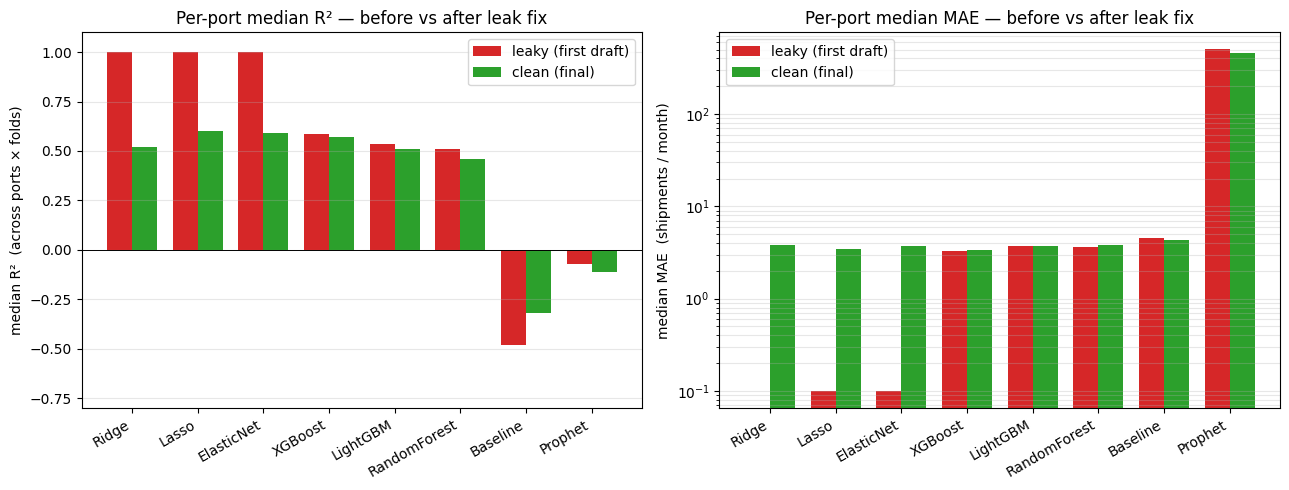

In [5]:
# ── Visualise the delta ──────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = [
    "ridge", "lasso", "elasticnet",
    "xgboost", "lightgbm", "random_forest",
    "baseline_seasonal_naive_covid_aware", "prophet",
]
label_short = {
    "ridge":"Ridge", "lasso":"Lasso", "elasticnet":"ElasticNet",
    "xgboost":"XGBoost", "lightgbm":"LightGBM", "random_forest":"RandomForest",
    "baseline_seasonal_naive_covid_aware":"Baseline", "prophet":"Prophet",
}
labels = [label_short[m] for m in models]

leak_r2  = [compare.loc[m, "leaky_r2"]  if m in compare.index else np.nan for m in models]
clean_r2 = [compare.loc[m, "clean_r2"]  if m in compare.index else np.nan for m in models]

x = np.arange(len(models))
w = 0.38
axes[0].bar(x - w/2, leak_r2,  width=w, color="#d62728", label="leaky (first draft)")
axes[0].bar(x + w/2, clean_r2, width=w, color="#2ca02c", label="clean (final)")
axes[0].axhline(0, color="black", lw=0.7)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=30, ha="right")
axes[0].set_ylabel("median R²  (across ports × folds)")
axes[0].set_title("Per-port median R² — before vs after leak fix")
axes[0].set_ylim(-0.8, 1.1)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

leak_mae  = [compare.loc[m, "leaky_mae"]  if m in compare.index else np.nan for m in models]
clean_mae = [compare.loc[m, "clean_mae"]  if m in compare.index else np.nan for m in models]

axes[1].bar(x - w/2, leak_mae,  width=w, color="#d62728", label="leaky (first draft)")
axes[1].bar(x + w/2, clean_mae, width=w, color="#2ca02c", label="clean (final)")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=30, ha="right")
axes[1].set_ylabel("median MAE  (shipments / month)")
axes[1].set_title("Per-port median MAE — before vs after leak fix")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3, which="both")

plt.tight_layout()
plt.show()

<a id="lessons"></a>
## 8  Lessons learned

Writing these down explicitly is the whole point of the notebook.

### 8.1  Red flags to watch for

| Symptom | What it really means |
|---------|---------------------|
| A linear model beats a tuned gradient-booster by more than a tiny margin on a noisy real-world dataset | Target leakage, probably via a constructed feature |
| CV metrics are the same across every fold and every port | The model is solving an identity, not forecasting |
| Pearson ρ with the target is exactly 1.0 inside some partition | The feature is (an affine rescaling of) the target |
| The feature exists in the parquet but *not* in the code that builds the inference-time input | Train/serve skew is almost guaranteed |

### 8.2  Guardrails adopted for the rest of the thesis

1. **Every new feature** that references the target (lags, rolling means,
   differences) is computed with **past-only** windows.  The SQL frame to
   use is `ROWS BETWEEN n PRECEDING AND 1 PRECEDING`, never `… AND CURRENT ROW`.
2. **Per-partition min/max normalisations** must carry an explicit
   `ORDER BY … ROWS BETWEEN …` frame *or* be computed only on rows strictly
   earlier than the current row.  A bare `PARTITION BY` window is a leak
   waiting to happen.
3. **Any feature that is only needed by a downstream aggregate** (like the
   congestion-index inputs) must be stored in a *separate* table from the
   ML feature parquet, so that a "grab all numeric columns" training loop
   can never accidentally ingest it.
4. **Every model notebook** in this thesis imports `FEATURE_COLS` from a
   single shared source (`wz_ml_utils.py`).  This way a leak fix only has
   to be applied in one place.
5. **A sanity-check step** — "does a linear baseline beat every tree model
   by a suspicious margin?" — is now part of the comparison notebook
   (notebook 08).  If it ever fires again, we investigate before writing
   anything up.

### 8.3  What this means for the thesis narrative

The original project slides (`waze_cargo.pptx`) presented LightGBM as the
production model with R² ≈ 0.91 and MAE ≈ 1106 shipments/month.  The honest,
leak-free number is closer to R² ≈ 0.57 (volume-weighted, three folds).
The thesis does **not** walk that number back quietly — it is the central
story of this notebook.  The original figure was not wrong so much as
**wrongly interpreted**: it was CV on leaky data, not true out-of-sample
accuracy.

The honest number is still perfectly defensible for a real-world Chilean
ports forecasting problem: we predict 35+ port-direction pairs with
non-stationary, COVID-disturbed count series, across 18 years of history,
using one model family per port.  A volume-weighted R² of 0.57 on this kind
of panel is not a disappointing result — it is the number the production
system can genuinely sustain when the distribution it is trained on matches
the one it is scored on.

That distinction — *the metric a model actually delivers* vs *the metric a
badly-set-up evaluation will report* — is the single most important lesson
this EDA taught the author, and the reason this notebook exists.
